# 01 · Exploration de la consommation électrique

**Question : à quoi ressemble la consommation française et qu'est-ce qui la fait varier ?**

Données : RTE éCO2mix régional. L'historique consolidé (versionné par DVC) est complété par les données temps réel de l'API RTE (`src/data.py`). La série nationale est la somme des 12 régions, au pas de 30 minutes.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

from src.data import load_series

series = load_series()
paris = series.assign(timestamp=series["timestamp"].dt.tz_convert("Europe/Paris")).set_index("timestamp")
series.head()

,timestamp,consommation_mw
0,2012-12-31 23:30:00+00:00,59662.0
1,2013-01-01 00:00:00+00:00,57866.0
2,2013-01-01 00:30:00+00:00,57747.0
3,2013-01-01 01:00:00+00:00,57234.0
4,2013-01-01 01:30:00+00:00,56649.0


## Qualité des données

In [2]:
steps = series["timestamp"].diff().value_counts()
print(f"Période : {series['timestamp'].min():%d/%m/%Y} → {series['timestamp'].max():%d/%m/%Y}")
print(f"Observations : {len(series):,} · valeurs manquantes : {series['consommation_mw'].isna().sum()}")
print(f"Doublons de timestamp : {series['timestamp'].duplicated().sum()}")
print("Pas de temps observés :")
steps.head()

Période : 31/12/2012 → 23/09/2026
Observations : 240,641 · valeurs manquantes : 0
Doublons de timestamp : 0
Pas de temps observés :


timestamp
0 days 00:30:00    240627
0 days 01:30:00        13
Name: count, dtype: int64

Le pas de 30 minutes est quasi parfait : seuls quelques trous d'1 h 30 subsistent. Ils seront laissés vides (pas d'interpolation) : on n'invente pas de données.

## Tendance de long terme

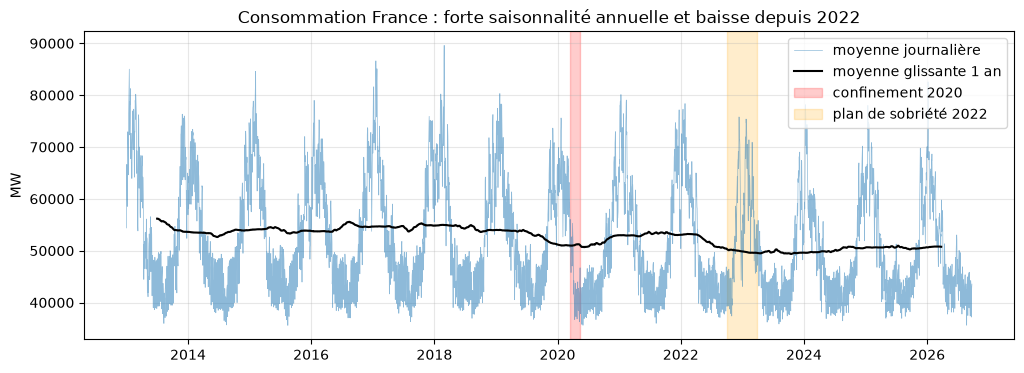

In [3]:
daily = paris["consommation_mw"].resample("D").mean()
fig, ax = plt.subplots()
ax.plot(daily.index, daily, linewidth=0.5, alpha=0.5, label="moyenne journalière")
ax.plot(daily.index, daily.rolling(365, center=True).mean(), color="black", label="moyenne glissante 1 an")
ax.axvspan(pd.Timestamp("2020-03-17", tz="Europe/Paris"), pd.Timestamp("2020-05-11", tz="Europe/Paris"), color="red", alpha=0.2, label="confinement 2020")
ax.axvspan(pd.Timestamp("2022-10-01", tz="Europe/Paris"), pd.Timestamp("2023-03-31", tz="Europe/Paris"), color="orange", alpha=0.2, label="plan de sobriété 2022")
ax.set(title="Consommation France : forte saisonnalité annuelle et baisse depuis 2022", ylabel="MW")
ax.legend(loc="upper right");

La saisonnalité annuelle domine (chauffage électrique en hiver). Deux ruptures sont visibles : le confinement de 2020 et la baisse durable depuis la crise énergétique de 2022. **Conséquence : le test doit porter sur la période la plus récente**, un découpage aléatoire mélangerait des régimes différents.

## Profil journalier et hebdomadaire

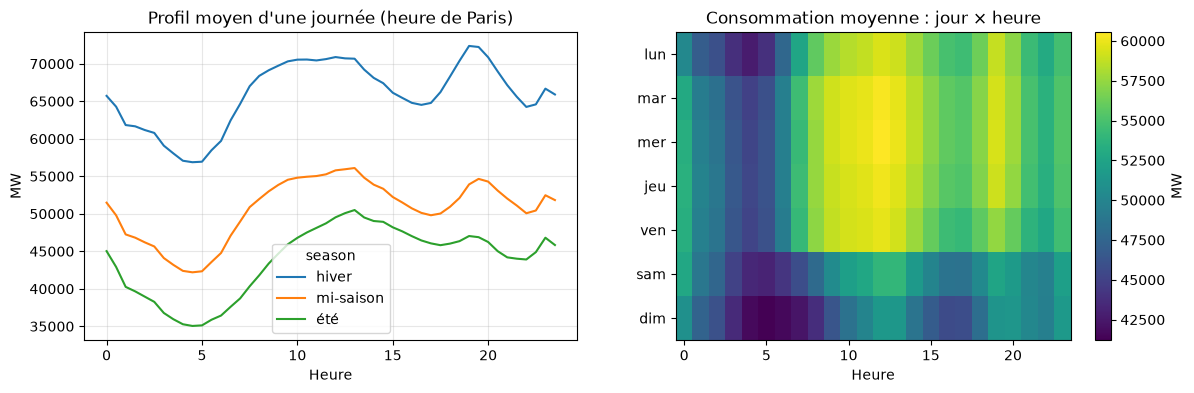

In [4]:
frame = paris[["consommation_mw"]].assign(
    hour=paris.index.hour + paris.index.minute / 60,
    season=np.where(paris.index.month.isin([12, 1, 2]), "hiver", np.where(paris.index.month.isin([6, 7, 8]), "été", "mi-saison")),
    dayofweek=paris.index.dayofweek,
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
frame.groupby(["hour", "season"])["consommation_mw"].mean().unstack().plot(ax=ax1, title="Profil moyen d'une journée (heure de Paris)")
ax1.set(xlabel="Heure", ylabel="MW")

heatmap = frame.groupby([frame["dayofweek"], frame.index.hour])["consommation_mw"].mean().unstack()
image = ax2.imshow(heatmap, aspect="auto", cmap="viridis")
ax2.set(title="Consommation moyenne : jour × heure", xlabel="Heure", yticks=range(7), yticklabels=["lun", "mar", "mer", "jeu", "ven", "sam", "dim"])
ax2.grid(False)
fig.colorbar(image, ax=ax2, label="MW");

Pics du matin et du soir (19 h en hiver), creux la nuit, week-end nettement plus bas. **L'heure, le jour de la semaine et le mois sont des variables indispensables**, et ils doivent être calculés en heure de Paris : en UTC, le pic se décalerait d'une heure au changement d'heure.

## Autocorrélation : quels retards (lags) utiliser ?

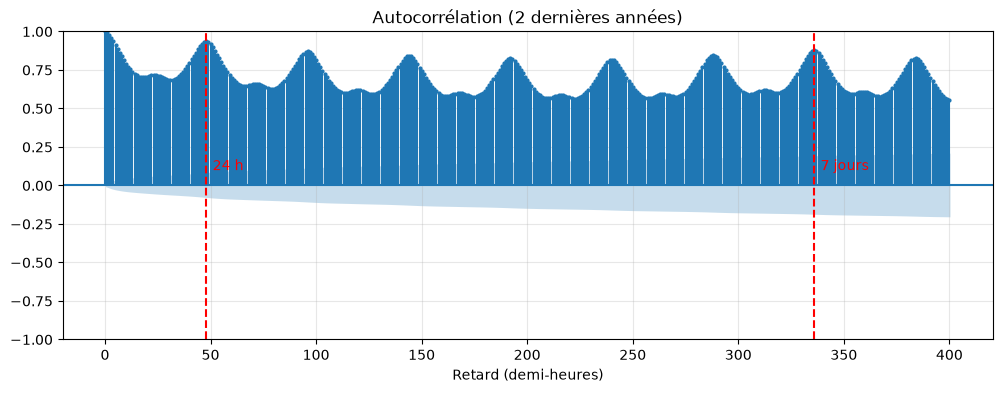

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

hourly = series.set_index("timestamp")["consommation_mw"]
recent_years = hourly[hourly.index > hourly.index.max() - pd.Timedelta(days=730)].interpolate()
fig, ax = plt.subplots()
plot_acf(recent_years, lags=400, ax=ax, markersize=2, title="Autocorrélation (2 dernières années)")
for lag, label in [(48, "24 h"), (336, "7 jours")]:
    ax.axvline(lag, color="red", linestyle="--")
    ax.text(lag + 3, 0.1, label, color="red")
ax.set_xlabel("Retard (demi-heures)");

Les pics d'autocorrélation à **48 demi-heures (24 h)** et **336 (7 jours)** justifient directement les variables `lag_48` et `lag_336` (plus `lag_96`, 48 h) utilisées au notebook 02.

## Répartition régionale

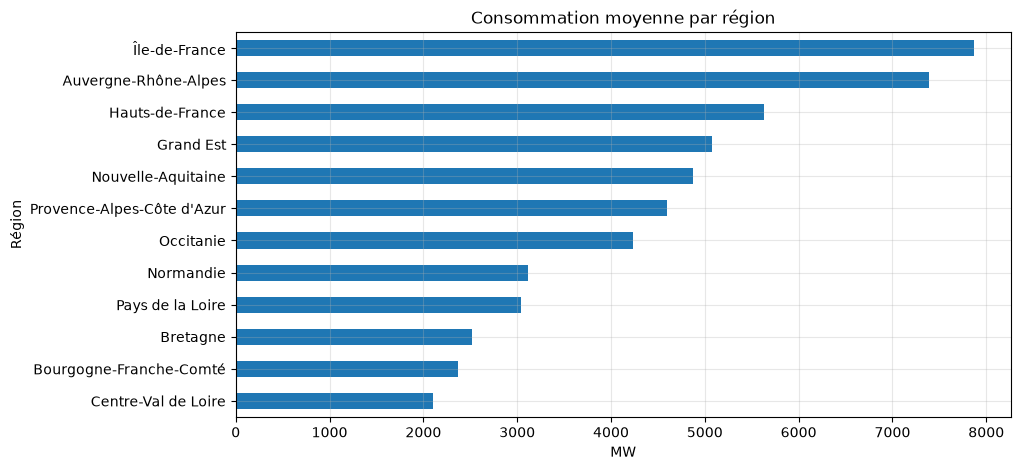

In [6]:
regional = pd.read_csv(ROOT / "data" / "eco2mix_regional.csv")
regional.groupby("Région")["consommation_mw"].mean().sort_values().plot.barh(title="Consommation moyenne par région", figsize=(10, 5))
plt.xlabel("MW");

## Conclusions

- Série propre, pas de 30 min, 12 régions toujours présentes.
- Saisonnalités journalière, hebdomadaire et annuelle → variables calendaires en heure de Paris.
- Autocorrélation forte à 24 h et 7 jours → lags.
- Ruptures de régime (2020, 2022) → découpage **temporel** et surveillance de la dérive (notebook 06).